# Tutorial 2: Vertical denoising and integration on DLPFC multi slices from 10x Visium 

In this tutorial, we evaluate the capability of STADIM in handling vertically adjacent slices. We use the human Dorsolateral Prefrontal Cortex (DLPFC) slice #151673-#151676 generated by 10x Visium platform as a representative example, which is annotated by Maynard et al. into white matter (WM) and cortical layers (L1-L6) based on marker genes and cellular structure.  
We download the data via http://spatial.libd.org/spatialLIBD/.

## Quick view data

151673
AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
151674
AnnData object with n_obs × n_vars = 3635 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
151675
AnnData object with n_obs × n_vars = 3566 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
151676
AnnData object with n_obs × n_vars = 3431 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


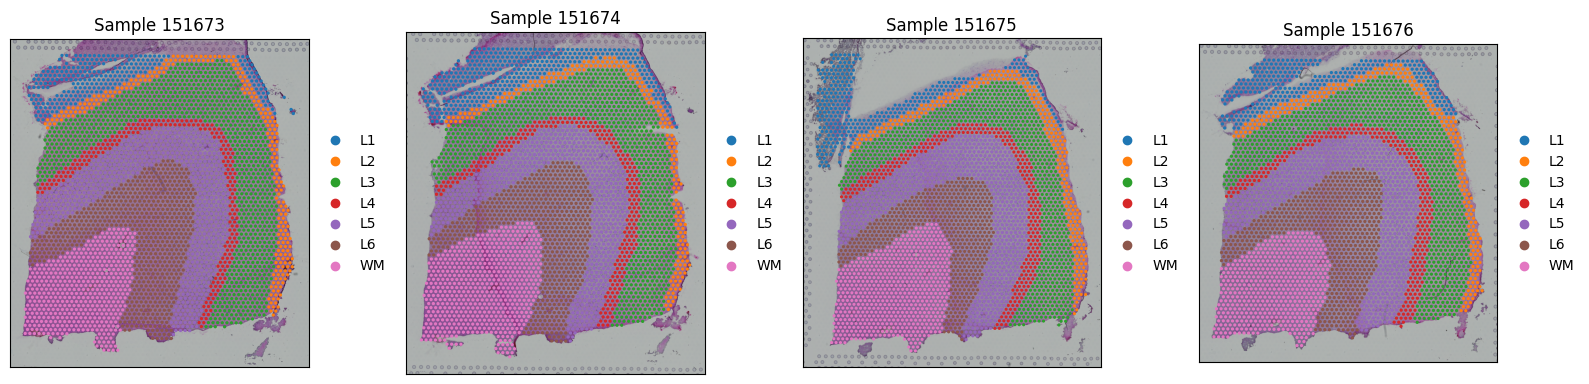

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

sample_ids = ['151673', '151674', '151675', '151676']
data_dir = '/data2/xiaost/SODA/Data/DLPFC/'

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, s_id in enumerate(sample_ids):
    adata = sc.read_h5ad(os.path.join(data_dir, f'dlpfc_{s_id}.h5ad'))
    print(f'{s_id}')
    print(adata)

    sc.pl.spatial(adata, color='Label', ax=axes[i], show=False, title=f'Sample {s_id}')
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Run STADIM

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./dlpfc_151673.h5ad" "./dlpfc_151674.h5ad" "./dlpfc_151675.h5ad" "./dlpfc_151676.h5ad" --save_preprocessed_h5ad None --save_dir ./dlpfc_donor1_test --device "cuda:0" --monitor --seed 2026 --min_genes 0 --min_cells 10 --knn_c 6 --knn_e 10 --mnn_n 25 > ./dlpfc_donor1_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis. The denoised expression matrix is conveniently stored within the `layers` attribute:
```python
import anndata as ad

adata = ad.read_h5ad('/dlpfc_donor1_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
or you can call STADIM within a Jupyter Notebook as follows:

In [2]:
import stadim

adata = stadim.run_STADIM(['/data2/xiaost/SODA/Data/DLPFC/dlpfc_151673.h5ad', '/data2/xiaost/SODA/Data/DLPFC/dlpfc_151674.h5ad', 
                          '/data2/xiaost/SODA/Data/DLPFC/dlpfc_151675.h5ad', '/data2/xiaost/SODA/Data/DLPFC/dlpfc_151676.h5ad'], 
                          save_preprocessed_h5ad=None, save_dir=None, 
                          sample_names=None, batch_key='sample', device='cuda:1', seed=2026, 
                          min_genes=0, min_cells=10, nhvgs=2000, dim=50, knn_c=6, knn_e=10, mnn_n=25,
                          batch_size=256, triplets_update_ratio=0.8, hard_triplets_ratio=0.7,
                          epochs=100, lr=1e-3, loss_mode='nb', beta_trip=0.1,
                          encoder_layers=[512, 256, 64], decoder_layers=[1000])

Results will be stored in adata.layers['STADIM']

=== 1. Begin read_data!
Detected multi-slice data, total 4 slices
  Slice 1: Using user-defined column 'sample' as sample
  Slice 1: Keeping existing sample label 151673
  Slice 2: Using user-defined column 'sample' as sample
  Slice 2: Keeping existing sample label 151674
  Slice 3: Using user-defined column 'sample' as sample
  Slice 3: Keeping existing sample label 151675
  Slice 4: Using user-defined column 'sample' as sample
  Slice 4: Keeping existing sample label 151676

Merging data...

Raw Merged Data: 14243 spots × 33538 genes
Unified Filtering (min_genes=0, min_cells=10)...
  → After Filtering: 14243 spots × 19326 genes
  ✓ Complete: Samples included: ['151673', '151674', '151675', '151676']
  ✓ Complete: AnnData object with n_obs × n_vars = 14243 × 19326
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
    layers

Preparing triplet: 100%|██████████| 14243/14243 [00:02<00:00, 6902.20it/s]



=== 5. Begin IterableTripletDataset!
Initializing triplets...
IterableTripletDataset Initialized: 14243 anchors, batch_size=256

=== 6. Begin calculate_recommended_margin!
Calculating recommended margin (averaging over 5 runs)...

Margins from 5 runs: [15.0, 15.0, 15.0, 15.0, 15.0]
Final Recommended Margin: 15.0000

=== 7. Starting training...
Begin training: device=cuda:1


Training: 100%|██████████| 100/100 [05:23<00:00,  3.24s/it, recon=0.306, triplet=1.794, total=0.486]



=== 8. Generating denoised expression...
   Data size (2.75e+08) is within limits. Allocating memory for denoised data.

All processes finished! Total time: 6.62 mins.


In [3]:
print(adata)

AnnData object with n_obs × n_vars = 14243 × 19326
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'spatial', 'log1p', 'top_hvgs'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


## Analysis

In [4]:
import anndata as ad
import pandas as pd
import scanpy as sc 
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
gene_exp_colors = sns.blend_palette(["#C9E2FF", "#eae6cc", '#e31a1c'], n_colors=100)
gene_exp_palette = LinearSegmentedColormap.from_list("gene_exp", gene_exp_colors)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
plt.rcParams.update({
    'font.size': 16, 
    'axes.labelsize': 18,  
    'axes.titlesize': 18,  
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16,  
    'legend.fontsize': 16,
})

styles = {
    'STADIM': {'color': '#d62728', 'marker': '*', 'ms': 10, 'lw': 2.5, 'zorder': 10},
    'X_norm': {'color': '#c7c7c7', 'marker': 'o', 'ms': 6, 'lw': 1.5, 'zorder': 5}
}

### Gene expression visualization

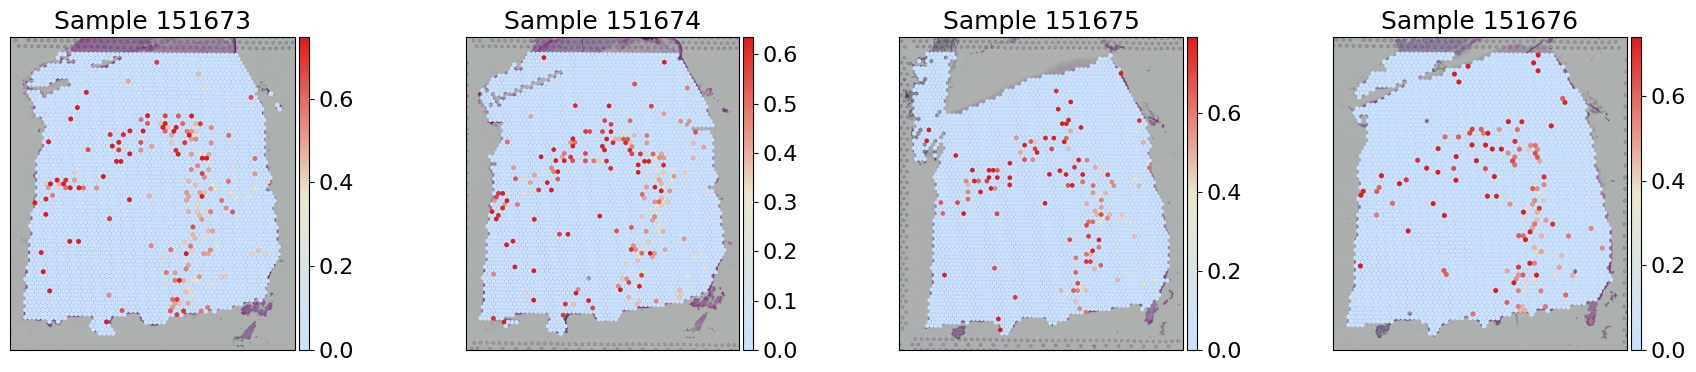

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, s_id in enumerate(sample_ids):
    sc.pl.spatial(adata[adata.obs['sample'] == s_id], layer='X_log', color='TRABD2A', cmap=gene_exp_palette, spot_size=150,
                  library_id=s_id, ax=axes[i], title=f"Sample {s_id}",show=False, vmax='p99')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

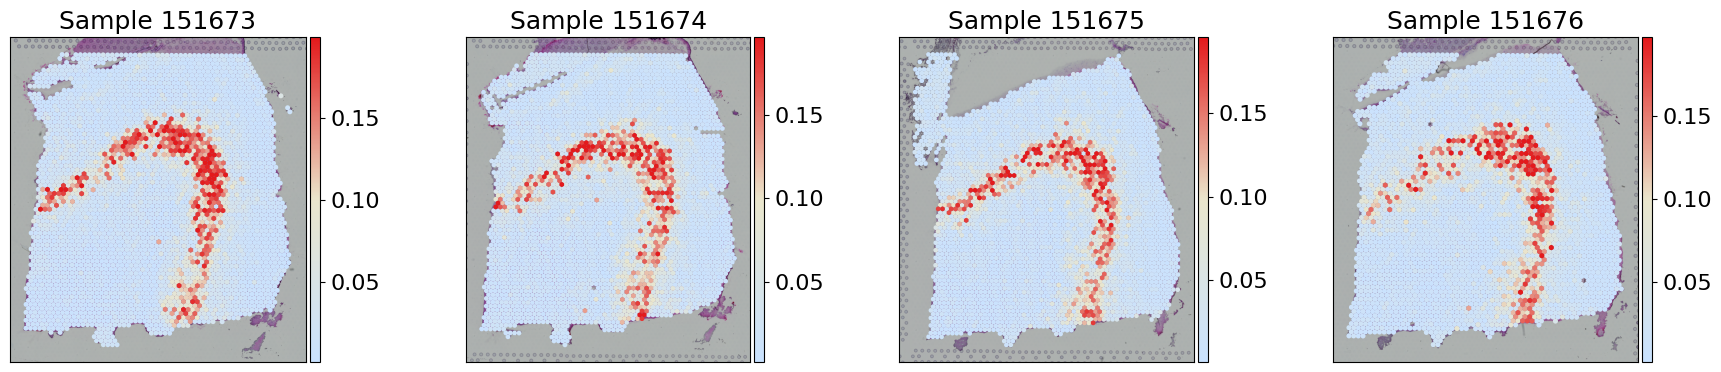

In [6]:
adata.X = adata.layers['STADIM'].copy()
sc.pp.log1p(adata)
adata.layers['STADIM_log'] = adata.X.copy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, s_id in enumerate(sample_ids):
    sc.pl.spatial(adata[adata.obs['sample'] == s_id], layer='STADIM_log', color='TRABD2A', cmap=gene_exp_palette, spot_size=150,
                  library_id=s_id, ax=axes[i], title=f"Sample {s_id}",show=False, vmax='p99')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Batch Entropy

In [7]:
%%time

res = stadim.calculate_batch_entropy(adata, test_layers=['X_norm', 'STADIM'], k_range=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
                                     group_key='Label', donor_id='DLPFC_Donor1', batch_key='sample', n_hvg=2000)

batch_entropy = pd.DataFrame(res)

display(batch_entropy)

,Method,Donor_ID,K,Avg_Entropy,Avg_Region_Ratio
0,X_norm,DLPFC_Donor1,10,0.561502,0.566145
1,X_norm,DLPFC_Donor1,20,0.639298,0.555410
2,X_norm,DLPFC_Donor1,30,0.675469,0.547668
3,X_norm,DLPFC_Donor1,40,0.697315,0.542279
4,X_norm,DLPFC_Donor1,50,0.712926,0.537930
5,X_norm,DLPFC_Donor1,60,0.725089,0.534229
6,X_norm,DLPFC_Donor1,70,0.735988,0.530475
7,X_norm,DLPFC_Donor1,80,0.744872,0.527497
8,X_norm,DLPFC_Donor1,90,0.752677,0.524724
9,X_norm,DLPFC_Donor1,100,0.759480,0.522301


CPU times: user 1min 29s, sys: 3.89 s, total: 1min 33s
Wall time: 40.6 s


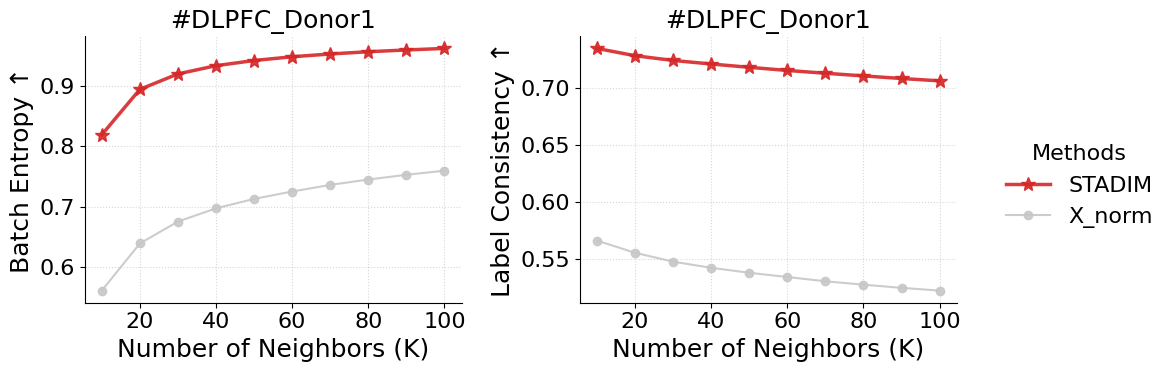

In [8]:
metrics = ['Avg_Entropy', 'Avg_Region_Ratio']
y_labels = ['Batch Entropy \u2191', 'Label Consistency \u2191']

plot_data = batch_entropy.groupby(['Method', 'K'])[metrics].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    for m in ['STADIM','X_norm']:
        data = plot_data[plot_data['Method'] == m].sort_values('K')
        if data.empty: continue
        
        ax.plot(data['K'], data[metric], label=m, 
                color=styles[m]['color'], marker=styles[m]['marker'],
                markersize=styles[m]['ms'], linewidth=styles[m]['lw'], 
                zorder=styles[m]['zorder'], alpha=0.9)

    ax.set_title(f"#DLPFC_Donor1")
    ax.set_xlabel('Number of Neighbors (K)')
    ax.set_ylabel(y_labels[i])
    ax.set_xticks([20, 40, 60, 80, 100])
    ax.grid(True, linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           title='Methods', frameon=False)

plt.tight_layout()
plt.show()

### weighted Coefficient of Variation (wCV)

In [9]:
benchmark_adata = stadim.create_shuffled_batches(adata, n_batches=5)
benchmark_adata.var = adata.var
print(f"\nbenchmark adata: {benchmark_adata}")


benchmark adata: AnnData object with n_obs × n_vars = 14243 × 19326
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor', 'sim_batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch', 'STADIM_log'


In [10]:
%%time

wcv = {}
for gene_type in ["HVGs", "LVGs"]:
    print(f"\ngene_type: {gene_type}")
    
    # wCV before and after STADIM 
    res_deno = stadim.calculate_cv(adata, batch_key='sample', label_key='Label', methods=['X_norm', 'STADIM'], gene_type=gene_type)
    
    # wCV of simulated benchmark no batch data, calculated with X_norm and shuffled labels
    res_bench = stadim.calculate_cv(benchmark_adata, batch_key='sim_batch', label_key='Label', methods=['X_norm'], gene_type=gene_type)
    res_bench = res_bench.rename(columns={'X_norm': 'Sim_NoBatch'})

    wcv[gene_type] = res_bench.join(res_deno, how='inner')

print(wcv["HVGs"].head())


gene_type: HVGs
--- Calculating CV on 2000 genes of type: HVGs ---
Methods successfully calculated: ['X_norm', 'STADIM']
--- Calculating CV on 2000 genes of type: HVGs ---
Methods successfully calculated: ['X_norm']

gene_type: LVGs
--- Calculating CV on 17326 genes of type: LVGs ---
Methods successfully calculated: ['X_norm', 'STADIM']
--- Calculating CV on 17326 genes of type: LVGs ---
Methods successfully calculated: ['X_norm']
            Sim_NoBatch    X_norm    STADIM
HES4           0.098084  0.125947  0.037362
VWA1           0.110024  0.116677  0.055306
AL645728.1     0.907844  0.635260  0.110994
FO704657.1     1.088555  0.903454  0.133141
AL109917.1     0.652083  0.713419  0.074418
CPU times: user 11.7 s, sys: 2.02 s, total: 13.7 s
Wall time: 13.7 s


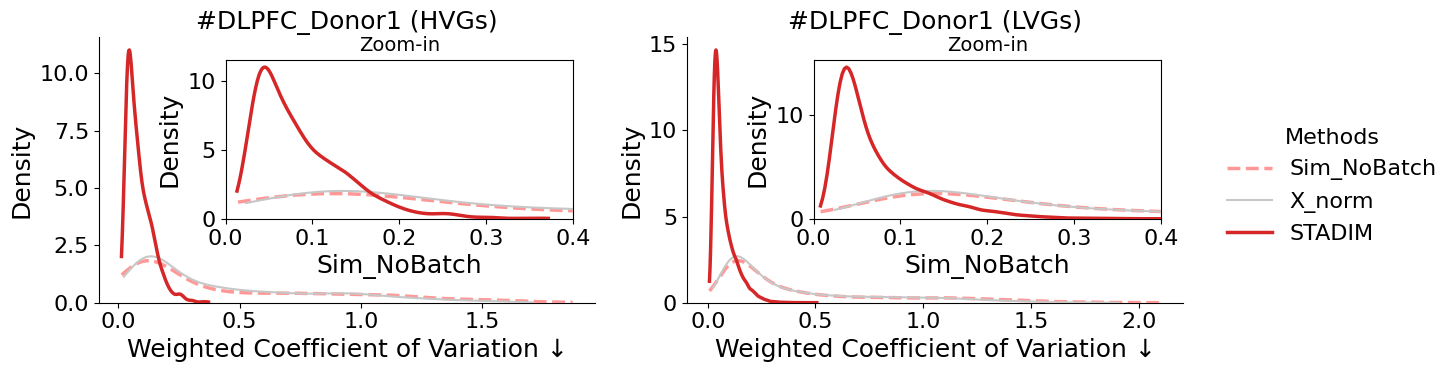

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

methods = ['Sim_NoBatch', 'X_norm', 'STADIM']
colors = {'Sim_NoBatch': '#ff9896', 'X_norm': '#c7c7c7', 'STADIM': '#d62728'}
gene_types = ['HVGs', 'LVGs']


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, g_type in enumerate(gene_types):
    ax = axes[i]
    df = wcv[g_type]
    
    ax_ins = inset_axes(ax, width="70%", height="60%", loc=1, borderpad=1)
    
    for m in methods:
        if m not in df.columns: continue

        style = {
            'label': m, 'color': colors.get(m, '#333333'), 'fill': False,
            'linewidth': 2.5 if m != 'X_norm' else 1.5,
            'linestyle': '--' if m == 'Sim_NoBatch' else '-',
            'zorder': 10 if m == 'STADIM' else 5,
            'cut': 0
        }
        
        sns.kdeplot(df[m].dropna(), ax=ax, **style)
        sns.kdeplot(df[m].dropna(), ax=ax_ins, **style)

    ax.set_title(f"#DLPFC_Donor1 ({g_type})")
    ax.set_xlabel("Weighted Coefficient of Variation \u2193")
    ax_ins.set_xlim(0, 0.4)
    ax_ins.set_title("Zoom-in", fontsize=14)
    sns.despine(ax=ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           title='Methods', frameon=False)

plt.tight_layout()
plt.show()

### Latent representation Umap

In [12]:
%%time

sc.pp.neighbors(adata, use_rep='STADIM', key_added=f'neighbors_STADIM')
sc.tl.umap(adata, neighbors_key=f'neighbors_STADIM')
adata.obsm['X_umap_STADIM'] = adata.obsm['X_umap'].copy()
print(adata)      

AnnData object with n_obs × n_vars = 14243 × 19326
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'spatial', 'log1p', 'top_hvgs', 'neighbors_STADIM', 'umap'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM', 'X_umap', 'X_umap_STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch', 'STADIM_log'
    obsp: 'neighbors_STADIM_distances', 'neighbors_STADIM_connectivities'
CPU times: user 4min 28s, sys: 225 ms, total: 4min 28s
Wall time: 1min 3s


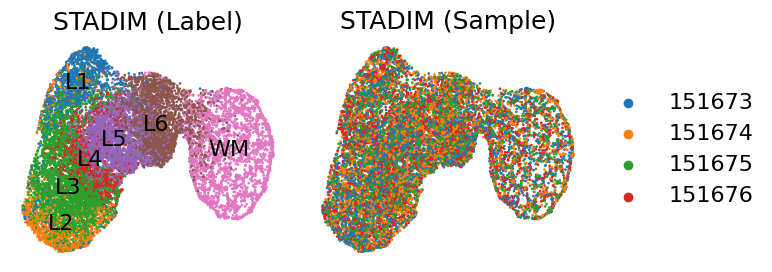

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sc.pl.embedding(adata, basis='X_umap_STADIM', color='Label', ax=axes[0], show=False, legend_loc='on data', legend_fontweight='normal',
                title='STADIM (Label)', frameon=False, s=15)

sc.pl.embedding(adata[np.random.permutation(adata.n_obs)], basis='X_umap_STADIM', color='sample', ax=axes[1], show=False, 
                title='STADIM (Sample)', frameon=False, s=15)

plt.tight_layout()
plt.show()